Import all the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("german_credit_risk.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [4]:
df.shape

(1000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
na_col = ["Saving accounts","Checking account"]
for col in na_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df= df.drop("Unnamed: 0", axis=1)

In [11]:
from sklearn.preprocessing import LabelEncoder
obj_cols = ["Sex","Housing","Saving accounts","Checking account","Purpose","Risk"]
encoder = LabelEncoder()
for cols in obj_cols:
    df[cols] = encoder.fit_transform(df[cols])

In [12]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,0,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
 9   Risk              1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB


In [14]:
df["Risk"].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15292\2140201561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette="Set2")


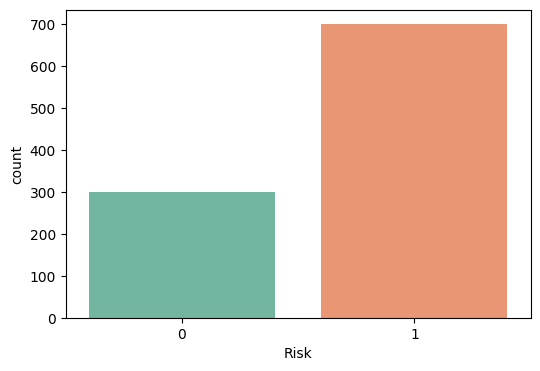

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Risk', data=df, palette="Set2")
plt.show()

In [16]:
df.corr()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
Age,1.000000,0.161694,0.015673,-0.301419,0.015772,-0.027176,0.032716,-0.036136,-0.074084,0.091127
Sex,0.161694,1.000000,0.070298,-0.219844,-0.014425,-0.012705,0.093482,0.081432,-0.063231,0.075493
Job,0.015673,0.070298,1.000000,-0.107191,-0.034596,-0.043277,0.285385,0.210910,-0.025326,-0.032735
Housing,-0.301419,-0.219844,-0.107191,1.000000,0.043324,-0.028196,-0.135632,-0.157049,0.020633,-0.019315
Saving accounts,0.015772,-0.014425,-0.034596,0.043324,1.000000,0.015763,-0.077929,-0.043274,-0.024817,0.102751
Checking account,-0.027176,-0.012705,-0.043277,-0.028196,0.015763,1.000000,0.006953,0.004163,0.018577,-0.052375
Credit amount,0.032716,0.093482,0.285385,-0.135632,-0.077929,0.006953,1.000000,0.624984,-0.151720,-0.154739
Duration,-0.036136,0.081432,0.210910,-0.157049,-0.043274,0.004163,0.624984,1.000000,-0.083459,-0.214927
Purpose,-0.074084,-0.063231,-0.025326,0.020633,-0.024817,0.018577,-0.151720,-0.083459,1.000000,0.061145
Risk,0.091127,0.075493,-0.032735,-0.019315,0.102751,-0.052375,-0.154739,-0.214927,0.061145,1.000000


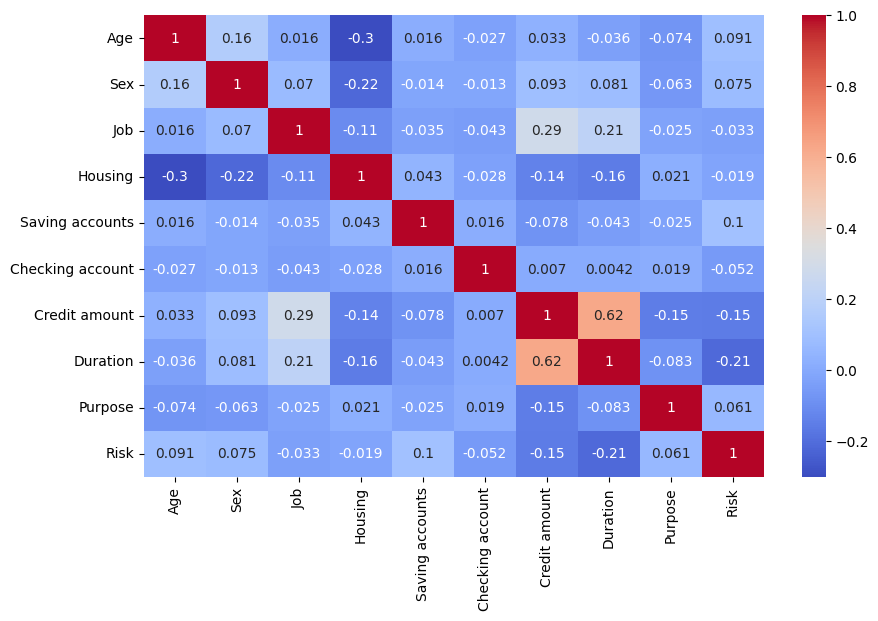

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [18]:
X = df.drop("Risk",axis=1)
y = df["Risk"]

In [19]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,1,2,1,0,0,1169,6,5
1,22,0,2,1,0,1,5951,48,5
2,49,1,1,1,0,0,2096,12,3
3,45,1,2,0,0,0,7882,42,4
4,53,1,2,0,0,0,4870,24,1
...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,0,1736,12,4
996,40,1,3,1,0,0,3857,30,1
997,38,1,2,1,0,0,804,12,5
998,23,1,2,0,0,0,1845,45,5


In [20]:
y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y ,test_size=0.2,random_state=42,stratify=y)

In [22]:
X_train_np = X_train.values
y_train_np = y_train.values

Entropy from scratch

In [23]:
def entropy(i):
    values, counts = np.unique(i,return_counts=True)
    probabilities_e = counts/counts.sum()
    return -np.sum(probabilities_e*np.log2(probabilities_e))

Gini from scratch

In [24]:
def gini(i):
    values,counts = np.unique(i,return_counts =True)
    probabilities_g = counts /counts.sum()
    return 1- np.sum(probabilities_g**2)

In [25]:
print("Total Entropy of y_train before splitting:",entropy(y_train_np))
print("Total Gini of y_train before splitting:",gini(y_train_np))

Total Entropy of y_train before splitting: 0.8812908992306927
Total Gini of y_train before splitting: 0.42000000000000004


IG for entropy

In [26]:
def information_gain(X,y,feature_index):
    total_entropy = entropy(y)
    values,counts = np.unique(X[:,feature_index],return_counts=True)
    
    weighted_entropy = 0
    for v in values:
        subset_y = y[X[:,feature_index]==v]
        weighted_entropy += (len(subset_y)/len(y)) * entropy(subset_y)

    return total_entropy - weighted_entropy

In [27]:
for k in range(X_train_np.shape[1]):
    ig = information_gain(X_train_np,y_train_np,k)
    print(f"Feature {k} -Information gain:{ig}")

Feature 0 -Information gain:0.051550403081833784
Feature 1 -Information gain:0.004816364394607531
Feature 2 -Information gain:0.001137182398385228
Feature 3 -Information gain:0.010192093342518027
Feature 4 -Information gain:0.010495653687964346
Feature 5 -Information gain:0.010980706778931926
Feature 6 -Information gain:0.834403680475284
Feature 7 -Information gain:0.06482814112979596
Feature 8 -Information gain:0.015695082467310106


Ig for gini

In [28]:
def information_gain_g(X,y,feature_index):
    total_gini = gini(y)
    values,counts = np.unique(X[:,feature_index],return_counts=True)
    
    weighted_gini = 0
    for v in values:
        subset_y = y[X[:,feature_index]==v]
        weighted_gini += (len(subset_y)/len(y)) * gini(subset_y)

    return total_gini - weighted_gini

In [29]:
for k in range(X_train_np.shape[1]):
    ig = information_gain_g(X_train_np,y_train_np,k)
    print(f"Feature {k} -Information gain:{ig}")

Feature 0 -Information gain:0.025850870880686938
Feature 1 -Information gain:0.0028509090909091817
Feature 2 -Information gain:0.0006923237457686082
Feature 3 -Information gain:0.006105946154235542
Feature 4 -Information gain:0.00533146007315638
Feature 5 -Information gain:0.006587820878433015
Feature 6 -Information gain:0.3966666666666667
Feature 7 -Information gain:0.03368285166144702
Feature 8 -Information gain:0.008944989545410953


Best Feature for root split using Entropy

In [30]:
def best_ig_e(X,y):
    best_feature = None
    best_ig = -1

    for i in range(X.shape[1]):
        ig = information_gain(X,y,i)
        if ig > best_ig:
            best_ig = ig
            best_feature = i
    print("Best Feature:", best_feature, "IG:", best_ig)

    return best_feature
best_ig_e(X_train_np,y_train_np)

Best Feature: 6 IG: 0.834403680475284


6

Best Feature for root split using gini

In [31]:
def best_ig_g(X,y):
    best_feature = None
    best_ig = -1

    for i in range(X.shape[1]):
        ig = information_gain_g(X,y,i)
        if ig > best_ig:
            best_ig = ig
            best_feature = i
    print("Best Feature:", best_feature, "IG:", best_ig)
    return best_feature
best_ig_g(X_train_np,y_train_np)

Best Feature:

 6 IG: 0.3966666666666667


6

Sample Data checking

In [32]:
import numpy as np

X_demo = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1],
    [0, 0, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1]
])
y_demo = np.array([0, 0, 0, 1, 1, 1, 1, 1])


In [33]:
print("Entropy Root:", entropy(y_demo))
print("Gini Root:", gini(y_demo))

for i in range(8):
    print(f"Feature {i} - IG (Entropy):", information_gain(X_demo, y_demo, i))
print(best_ig_g(X_demo,y_demo))



Entropy Root: 0.954434002924965
Gini Root: 0.46875
Feature 0 - IG (Entropy): 0.5487949406953987
Feature 1 - IG (Entropy): 0.04879494069539858
Feature 2 - IG (Entropy): 0.0
Feature 3 - IG (Entropy): 0.0
Feature 4 - IG (Entropy): 0.0
Feature 5 - IG (Entropy): 0.0
Feature 6 - IG (Entropy): 0.0
Feature 7 - IG (Entropy): 0.0
Best Feature: 0 IG: 0.28125
0


Build Simple decision tree from scratch

In [34]:
def build_tree(X,y,depth = 0 , max_depth = 3,split_number=1):
    # If max depth is reached or all labels are the same, return a leaf node
    if depth == max_depth or len(np.unique(y)) == 1:
        return np.unique(y,return_counts = True)[0][0]
    # Find the best feature to split on using the entropy-based function you've defined
    best_feature = best_ig_g(X,y)

    print(f"Split {split_number}: Best Feature = Feature {best_feature}")

    # Initialize the tree node
    tree = {'feature': best_feature, 'nodes': {}}

    # Recur for each unique value of the best feature
    next_split_number = split_number + 1
    # Recur for each unique value of the best feature
    for value in np.unique(X[:,best_feature]):
        subset_indices = X[:,best_feature] == value
        subset_X = X[subset_indices]
        subset_y = y[subset_indices]

        #Recursively biuld the subtree for this split
        tree['nodes'][value] = build_tree(subset_X,subset_y, depth +1 , max_depth,next_split_number)
    return tree

In [35]:
def predict(tree, sample):
    if not isinstance(tree,dict):
        return tree
    feature = tree['feature']
    if sample[feature] in tree['nodes']:
        return predict(tree['nodes'][sample[feature]],sample)
    else:
        return None

In [36]:
tree = build_tree(X_train_np,y_train_np)

sample = X_train_np[0]
prediction = predict(tree, sample)
print("Prediction:",prediction)

Best Feature: 6 IG: 0.3966666666666667
Split 1: Best Feature = Feature 6
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.4444444444444444
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.4444444444444444
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Spl

In [37]:
tree = build_tree(X_train_np,y_train_np)

sample = X_train_np[0]
prediction = predict(tree, sample)
print("Prediction:",prediction)

Best Feature: 6 IG: 0.3966666666666667
Split 1: Best Feature = Feature 6
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.4444444444444444
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.4444444444444444
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Split 2: Best Feature = Feature 0
Best Feature: 0 IG: 0.5
Spl

In [38]:
def trace_prediction(tree, sample, feature_names):
    node = tree
    depth = 0
    while isinstance(node, dict):  # While we’re not at a leaf
        feature_index = node['feature']
        feature_name = feature_names[feature_index]
        feature_value = sample[feature_index]
        print(f"Depth {depth}: Split on {feature_name}, value = {feature_value}")
        if feature_value in node['nodes']:
            node = node['nodes'][feature_value]
        else:
            print("Value not found in tree nodes, prediction might be None.")
            return None
        depth += 1
    print(f"Prediction: {node}")
    return node

# Now we can trace three sample predictions
samples_to_test = [X_train_np[0], X_train_np[1], X_train_np[2]]  # Just as examples
feature_names = X_train.columns.tolist()
for i, sample in enumerate(samples_to_test, start=1):
    print(f"\nTracing prediction for Sample {i}:")
    trace_prediction(tree, sample, feature_names)



Tracing prediction for Sample 1:
Depth 0: Split on Credit amount, value = 4530
Prediction: 1

Tracing prediction for Sample 2:
Depth 0: Split on Credit amount, value = 2503
Prediction: 1

Tracing prediction for Sample 3:
Depth 0: Split on Credit amount, value = 1567
Prediction: 1


In [ ]:
from sklearn.tree import DecisionTreeClassifier

depths = [2, 4, 6, 10, None]
trees = {}

for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    trees[d] = dt

print("Training completed for depths:", depths)


Training completed for depths: [2, 4, 6, 10, None]


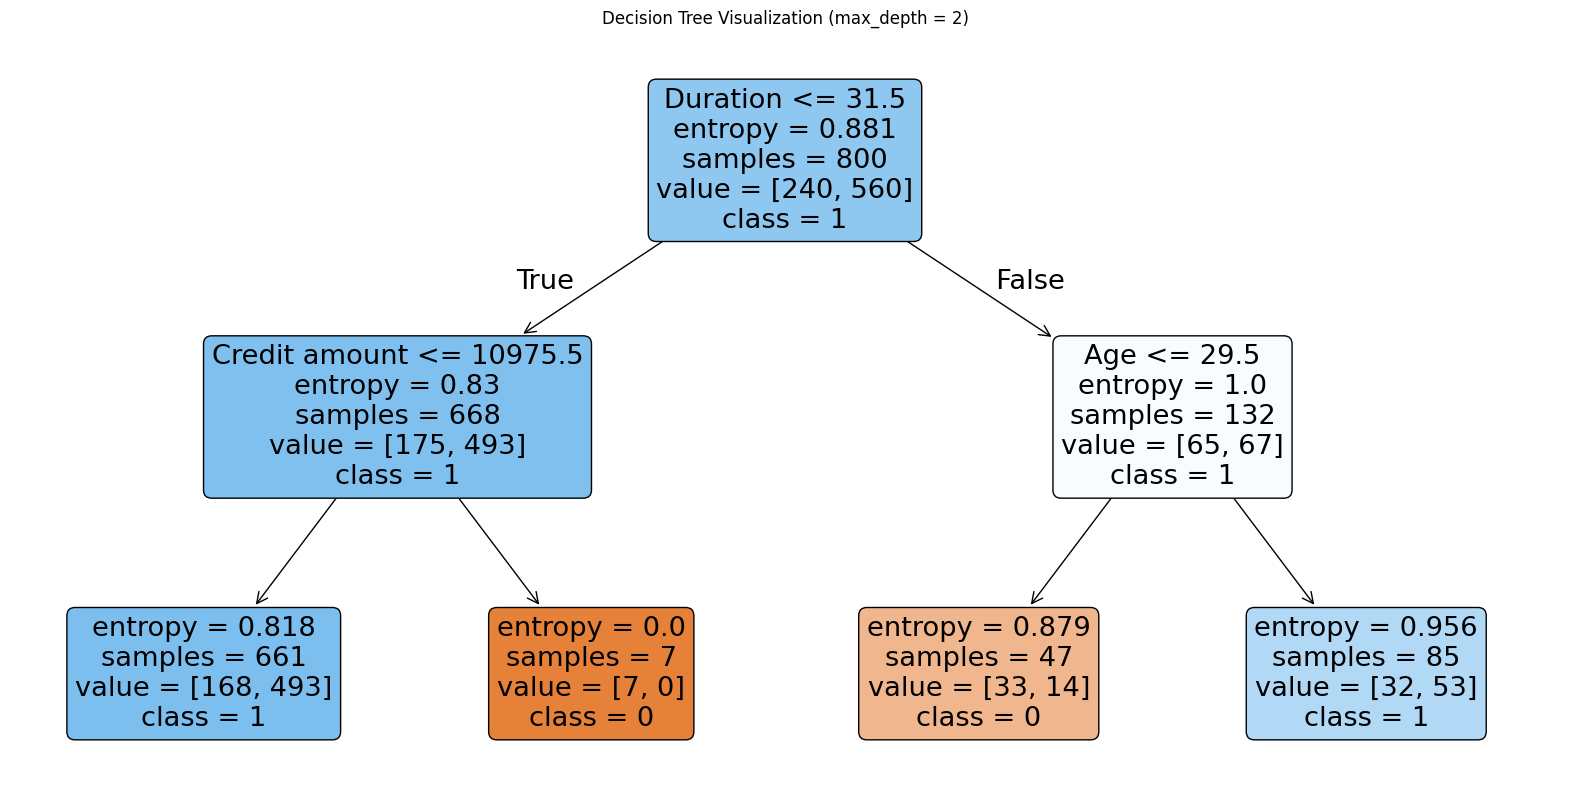

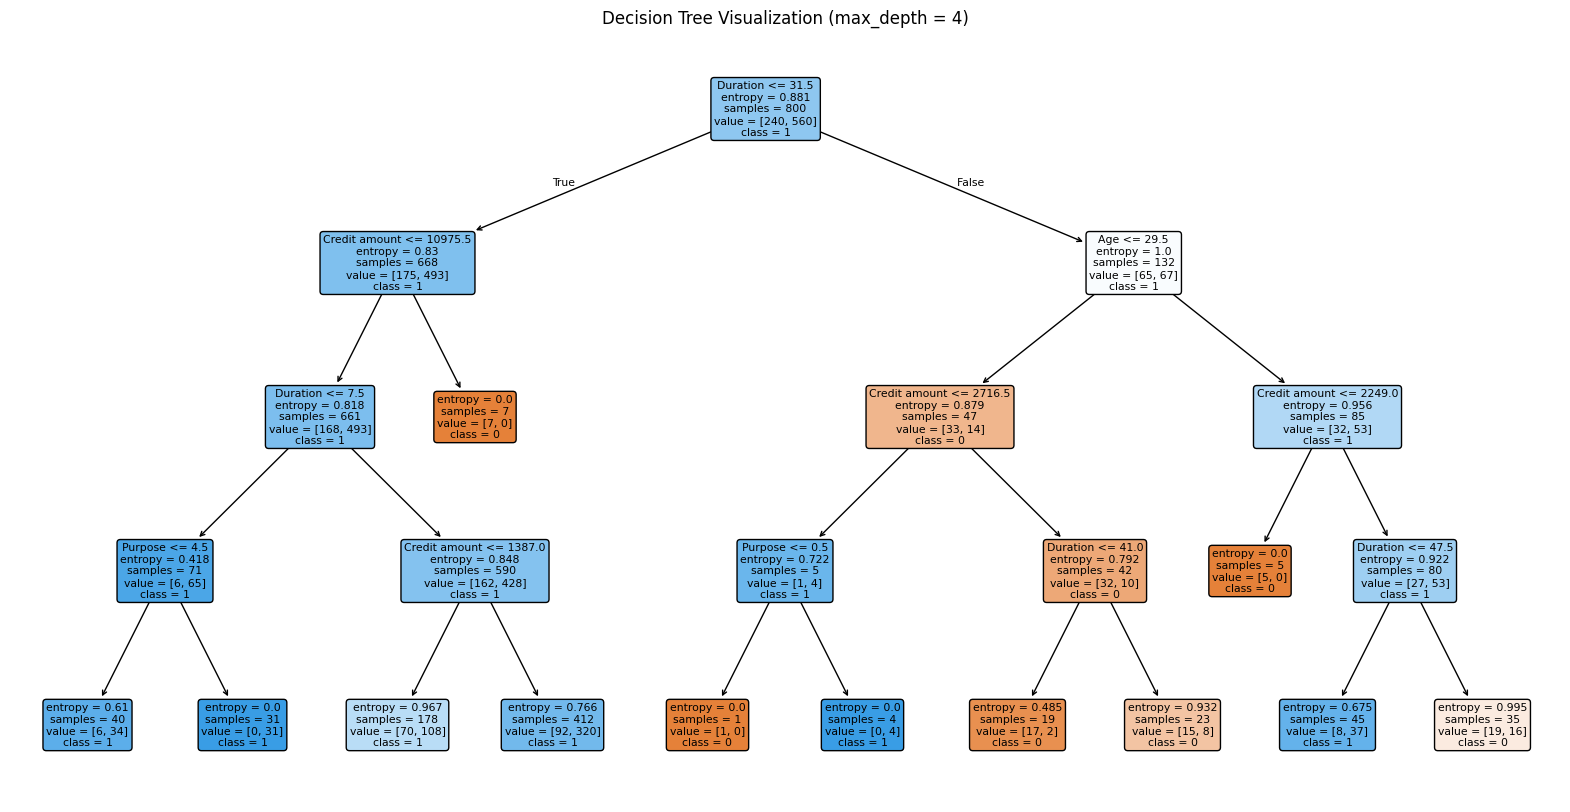

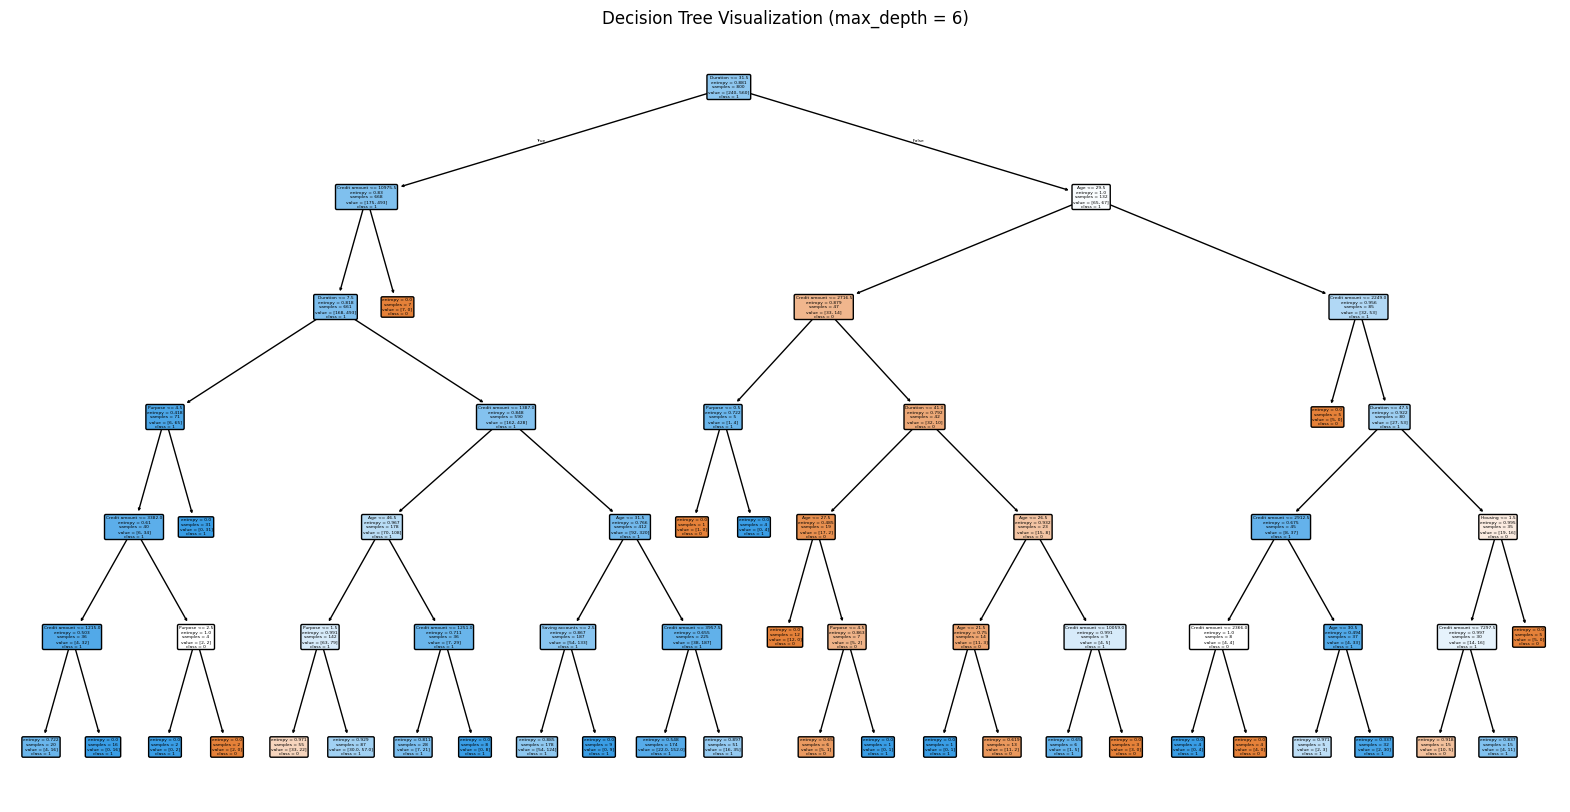

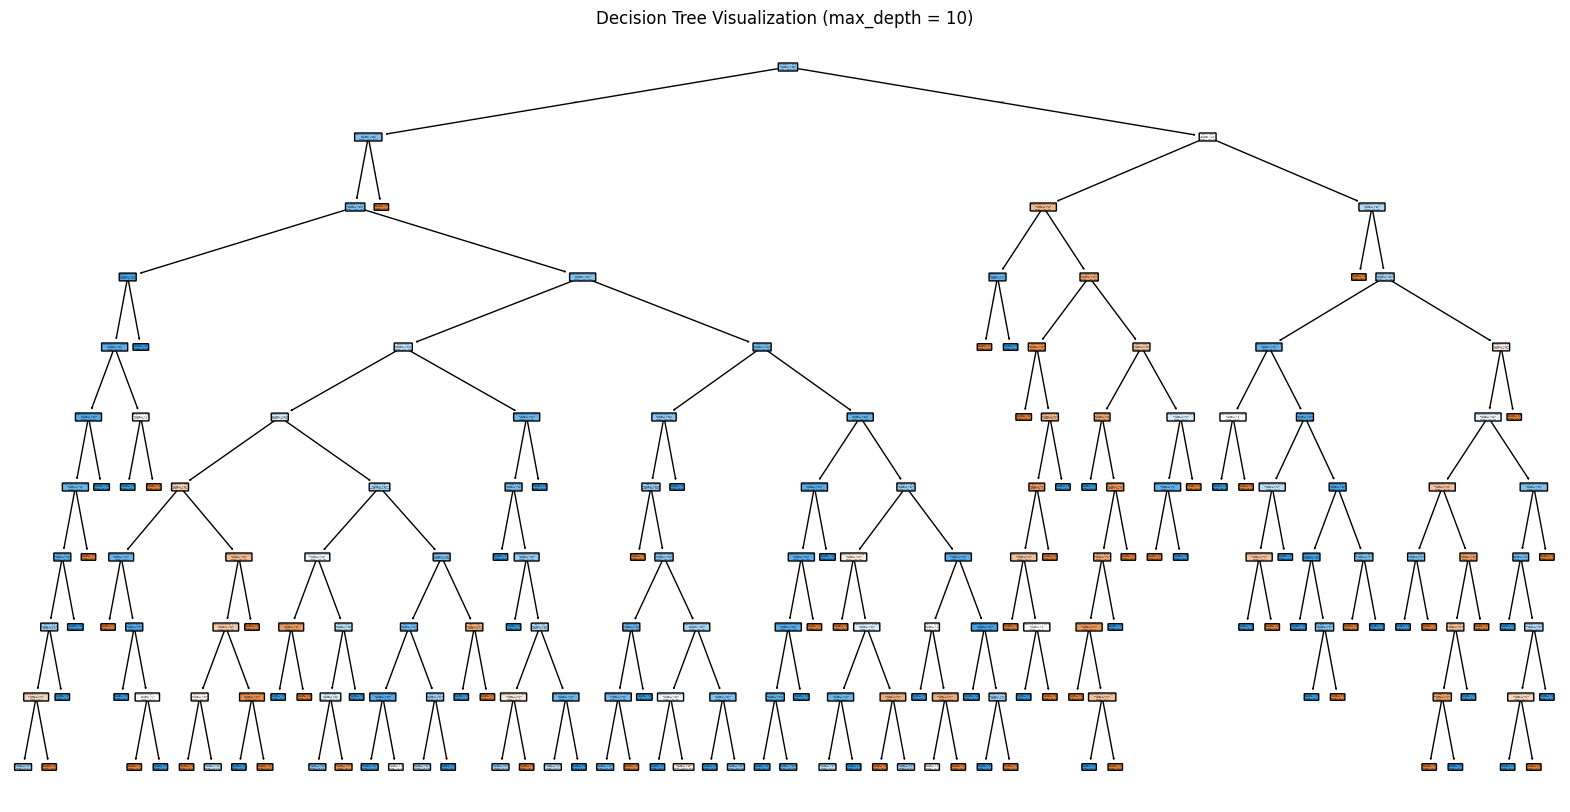

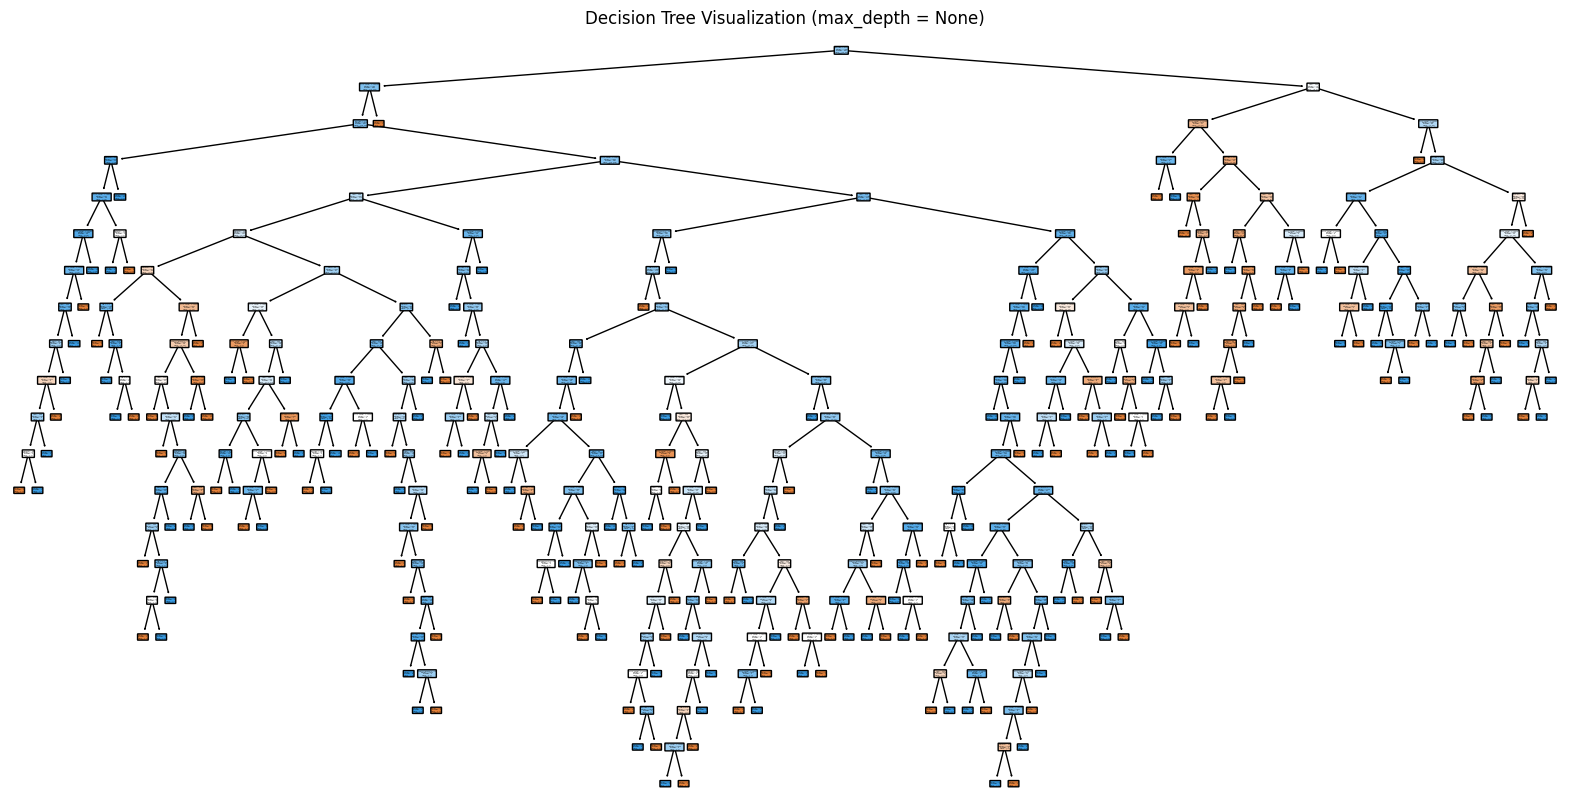

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for d in depths:
    plt.figure(figsize=(20,10))
    plot_tree(
        trees[d],
        feature_names=X_train.columns,
        class_names=['0','1'],
        filled=True,
        rounded=True
    )
    plt.title(f"Decision Tree Visualization (max_depth = {d})")
    plt.show()


In [ ]:
print("\nROOT SPLIT FEATURE FOR EACH max_depth:")
for d in depths:
    root_feature_idx = trees[d].tree_.feature[0]
    print(f"max_depth = {d} → Root Feature = {X_train.columns[root_feature_idx]}")




ROOT SPLIT FEATURE FOR EACH max_depth:
max_depth = 2 → Root Feature = Duration
max_depth = 4 → Root Feature = Duration
max_depth = 6 → Root Feature = Duration
max_depth = 10 → Root Feature = Duration
max_depth = None → Root Feature = Duration


In [ ]:
from sklearn.metrics import accuracy_score

train_acc_list = []
test_acc_list = []

for d in depths:
    model = trees[d]  # use the stored trained model
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"max_depth = {d} → Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")


max_depth = 2 → Train Acc = 0.7325, Test Acc = 0.7150
max_depth = 4 → Train Acc = 0.7475, Test Acc = 0.7000
max_depth = 6 → Train Acc = 0.7850, Test Acc = 0.6750
max_depth = 10 → Train Acc = 0.8725, Test Acc = 0.6200
max_depth = None → Train Acc = 1.0000, Test Acc = 0.6350


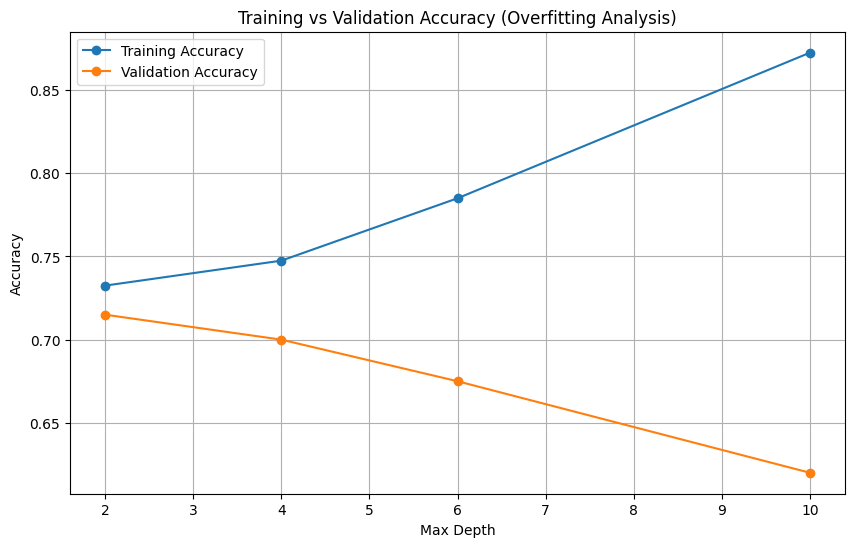

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_acc_list, marker='o', label="Training Accuracy")
plt.plot(depths, test_acc_list, marker='o', label="Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Overfitting Analysis)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for i in range(1, len(depths)):
    if test_acc_list[i] < test_acc_list[i-1]:
        print("\n📌 Overfitting starts at max_depth =", depths[i])
        break



📌 Overfitting starts at max_depth = 4


In [ ]:
unpruned_tree = trees[None]  # max_depth=None → full tree

train_pred_full = unpruned_tree.predict(X_train)
test_pred_full  = unpruned_tree.predict(X_test)

print("\nUnpruned Tree Training Accuracy:", accuracy_score(y_train, train_pred_full))
print("Unpruned Tree Test Accuracy:", accuracy_score(y_test, test_pred_full))



Unpruned Tree Training Accuracy: 1.0
Unpruned Tree Test Accuracy: 0.635


In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20]
}
dtc = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
grid_search = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [47]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)


Best Hyperparameters:
{'max_depth': 3, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.70625


In [48]:
best_dt = grid_search.best_estimator_

best_dt.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [49]:
from sklearn.tree import export_text

tree_rules = export_text(
    best_dt,
    feature_names=list(X_train.columns),
    max_depth=3
)

print(tree_rules)


|--- Duration <= 31.50
|   |--- Credit amount <= 10975.50
|   |   |--- Duration <= 7.50
|   |   |   |--- class: 1
|   |   |--- Duration >  7.50
|   |   |   |--- class: 1
|   |--- Credit amount >  10975.50
|   |   |--- class: 0
|--- Duration >  31.50
|   |--- Age <= 29.50
|   |   |--- Credit amount <= 2716.50
|   |   |   |--- class: 1
|   |   |--- Credit amount >  2716.50
|   |   |   |--- class: 0
|   |--- Age >  29.50
|   |   |--- Credit amount <= 2249.00
|   |   |   |--- class: 0
|   |   |--- Credit amount >  2249.00
|   |   |   |--- class: 1



In [ ]:
# New sample
new_sample = [[67, 1, 2, 1, 0, 0, 1169, 6, 5],
              [22, 0, 2, 1, 0, 1, 5951, 48, 5]]

# Prediction
pred = best_dt.predict(new_sample)

print("Prediction:", pred)

Prediction: [1 0]


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
